# Imports

In [1]:
import numpy as np
import sympy as sp
from numba import njit, prange

Mis funciones definidas en `/code/src/`

In [2]:
import sys
import os

# Navigate up to the 'code' directory, then into 'src'
sys.path.append(os.path.abspath('../src'))

# Import the functions
from dynamics import generate_orbit, generate_escape_time_fractal, generate_fatou_basins, make_generate_orbit_jitted, make_generate_escape_time_fractal_jitted, make_generate_fatou_basins_jitted
from utils import DynamicsPlotter

# Newton's Approximation

## Degree 2

In [21]:
z, α, β = sp.symbols('z α β', complex=True)

P = (z - α)*(z - β)
print(P)
P_prime = P.diff(z)
print(P_prime)

(z - α)*(z - β)
2*z - α - β


<Axes: title={'center': 'Fatou Basins of Attraction'}, xlabel='$\\mathrm{Re}(z)$', ylabel='$\\mathrm{Im}(z)$'>

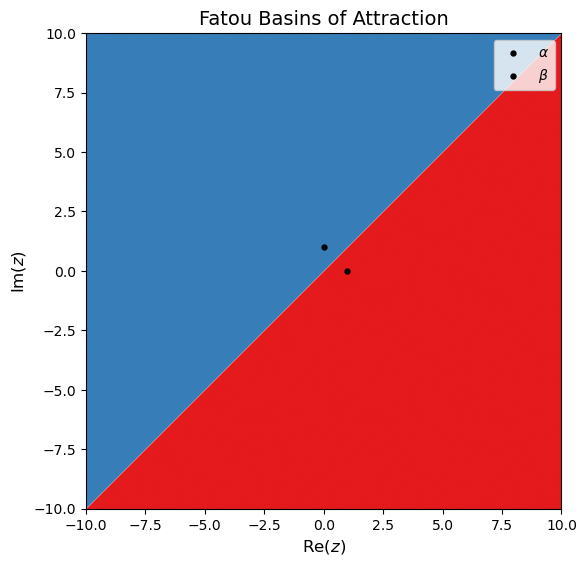

In [38]:
alpha = 1 + 0j
beta = 0 + 1j

@njit
def R_njit(z):
    return z - ((z-alpha)*(z-beta))/(2*z - alpha - beta)

generate_fatou_basins_jitted = make_generate_fatou_basins_jitted(R_njit)

center = 0.0
max_distance_to_center = 10

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 1e2

attractors = np.array([alpha, beta], dtype=np.complex128)
basins = generate_fatou_basins_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=1e-6)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

# Plot 1: The solid colored basins
fig, ax = plotter.plot_fatou_basins(basins)
plotter.add_points(ax, [alpha], label=rf"$\alpha$", marker='.', color='black', s=50, zorder=10)
plotter.add_points(ax, [beta], label=rf"$\beta$", marker='.', color='black', s=50, zorder=10)

En general, los puntos que están más cerca de $\alpha$ que de $\beta$ convergen a $\alpha$, y viceversa.

## Degree 3

In [39]:
z, α, β, γ = sp.symbols('z α β γ', complex=True)

P = (z - α)*(z - β)*(z - γ)
print(P)
P_prime = P.diff(z)
print(P_prime)

(z - α)*(z - β)*(z - γ)
(z - α)*(z - β) + (z - α)*(z - γ) + (z - β)*(z - γ)


<Axes: title={'center': 'Fatou Basins of Attraction'}, xlabel='$\\mathrm{Re}(z)$', ylabel='$\\mathrm{Im}(z)$'>

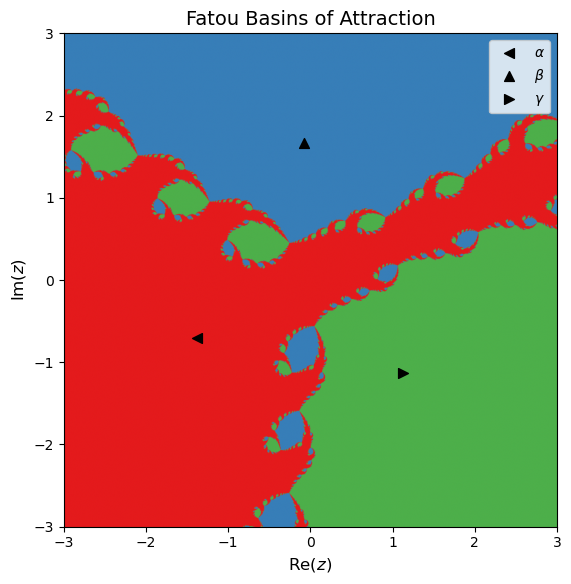

In [132]:
alpha = complex(np.random.uniform(-2, 2), np.random.uniform(-2, 2))
beta = complex(np.random.uniform(-2, 2), np.random.uniform(-2, 2))
gamma = complex(np.random.uniform(-2, 2), np.random.uniform(-2, 2))

@njit
def R_njit(z):
    return z - ((z-alpha)*(z-beta)*(z-gamma))/((z - alpha)*(z - beta) + (z - alpha)*(z - gamma) + (z - beta)*(z - gamma))

generate_fatou_basins_jitted = make_generate_fatou_basins_jitted(R_njit)

center = 0.0
max_distance_to_center = 3

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 2000
vertical_pixels = 2000

max_iter = 1e2

attractors = np.array([alpha, beta, gamma], dtype=np.complex128)
basins = generate_fatou_basins_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=1e-6)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

# Plot 1: The solid colored basins
fig, ax = plotter.plot_fatou_basins(basins)
plotter.add_points(ax, [alpha], label=rf"$\alpha$", marker='<', color='black', s=50, zorder=10)
plotter.add_points(ax, [beta], label=rf"$\beta$", marker='^', color='black', s=50, zorder=10)
plotter.add_points(ax, [gamma], label=rf"$\gamma$", marker='>', color='black', s=50, zorder=10)

<Axes: title={'center': 'Fatou Basins of Attraction'}, xlabel='$\\mathrm{Re}(z)$', ylabel='$\\mathrm{Im}(z)$'>

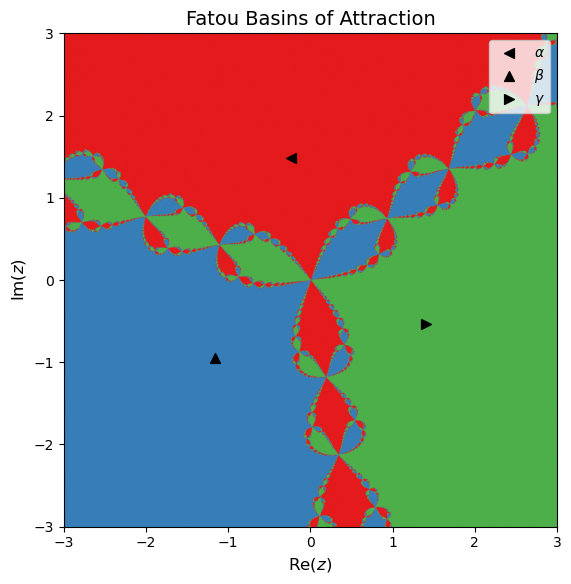

In [ ]:
radius = 1.5
angle = np.random.uniform(0, 2*np.pi)
alpha = radius*np.exp(angle*1j)
beta = radius*np.exp((angle + 2/3*np.pi)*1j)
gamma = radius*np.exp((angle + 4/3*np.pi)*1j)

@njit
def R_njit(z):
    return z - ((z-alpha)*(z-beta)*(z-gamma))/((z - alpha)*(z - beta) + (z - alpha)*(z - gamma) + (z - beta)*(z - gamma))

generate_fatou_basins_jitted = make_generate_fatou_basins_jitted(R_njit)

center = 0.0
max_distance_to_center = 3

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 1e3

attractors = np.array([alpha, beta, gamma], dtype=np.complex128)
basins = generate_fatou_basins_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=1e-6)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

# Plot 1: The solid colored basins
fig, ax = plotter.plot_fatou_basins(basins)
plotter.add_points(ax, [alpha], label=rf"$\alpha$", marker='<', color='black', s=50, zorder=10)
plotter.add_points(ax, [beta], label=rf"$\beta$", marker='^', color='black', s=50, zorder=10)
plotter.add_points(ax, [gamma], label=rf"$\gamma$", marker='>', color='black', s=50, zorder=10)

### Ejemplo del libro

In [53]:
z = sp.symbols('z', complex=True)

P = z**3 - 1
print(P)
P_prime = P.diff(z)
print(P_prime)
roots = sp.solve(P, z)
print(roots)

z**3 - 1
3*z**2
[1, -1/2 - sqrt(3)*I/2, -1/2 + sqrt(3)*I/2]


<Axes: title={'center': 'Fatou Basins of Attraction'}, xlabel='$\\mathrm{Re}(z)$', ylabel='$\\mathrm{Im}(z)$'>

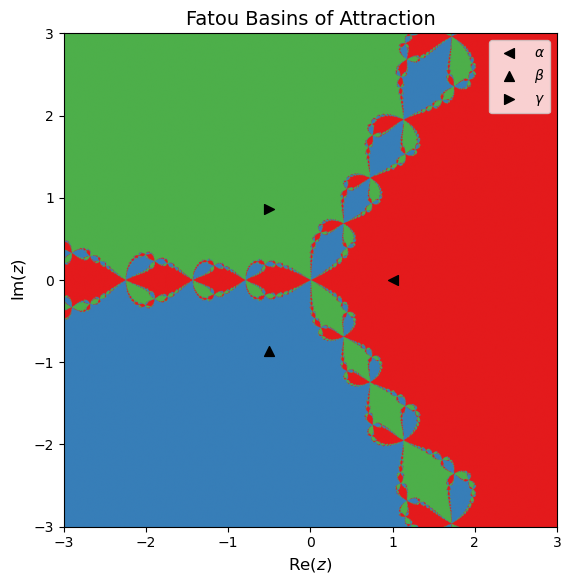

In [85]:
alpha = complex(1, 0)
beta = complex(-1/2, -np.sqrt(3)*1/2)
gamma = complex(-1/2, np.sqrt(3)*1/2)

@njit
def R_njit(z):
    return z - ((z-alpha)*(z-beta)*(z-gamma))/((z - alpha)*(z - beta) + (z - alpha)*(z - gamma) + (z - beta)*(z - gamma))

generate_fatou_basins_jitted = make_generate_fatou_basins_jitted(R_njit)

center = 0.0
max_distance_to_center = 3

xmin = center.real-max_distance_to_center
xmax = center.real+max_distance_to_center
ymin = center.imag-max_distance_to_center
ymax = center.imag+max_distance_to_center

horizontal_pixels = 1000
vertical_pixels = 1000

max_iter = 1e3

attractors = np.array([alpha, beta, gamma], dtype=np.complex128)
basins = generate_fatou_basins_jitted(xmin, xmax, ymin, ymax, horizontal_pixels, vertical_pixels, attractors, max_iter=max_iter, tolerance=1e-6)

plotter = DynamicsPlotter(xmin, xmax, ymin, ymax)

# Plot 1: The solid colored basins
fig, ax = plotter.plot_fatou_basins(basins)
plotter.add_points(ax, [alpha], label=rf"$\alpha$", marker='<', color='black', s=50, zorder=10)
plotter.add_points(ax, [beta], label=rf"$\beta$", marker='^', color='black', s=50, zorder=10)
plotter.add_points(ax, [gamma], label=rf"$\gamma$", marker='>', color='black', s=50, zorder=10)